In [ ]:
import warnings
warnings.filterwarnings('ignore') # Suppress warning messages for cleaner output

# Standard library
import os
import gzip
import string
from collections import Counter
from pprint import pprint

# Data & numerical computing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# NLP
import nltk
nltk.download('punkt')      # Download tokenizer models
nltk.download('punkt_tab')
nltk.download('stopwords')  # Download stopword lists
path = nltk.data.find('corpora/stopwords')
os.listdir(path)

from nltk.corpus import stopwords
from nltk.text import TextCollection
from nltk.collocations import BigramCollocationFinder
from nltk.metrics.association import BigramAssocMeasures

# Machine learning
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

# Utilities
from tqdm import tqdm

np.random.seed(123)
tqdm.pandas()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\yuliy\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\yuliy\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\yuliy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Tokenization

In [ ]:
# Example text that will be processed with NLP methods
text = """'Mary' had a little lamb,
    Little lamb, little lamb.
    MARY had a little lamb,
    Its fleece was white as snow.

    And everywhere that Mary went,
    Mary went, Mary went,
    Everywhere that Mary' went,
    The lamb was sure to go."""

In [ ]:
# Tokenize the text into words using NLTK
tokens = nltk.word_tokenize(text)

In [11]:
pprint(tokens)

["'Mary",
 "'",
 'had',
 'a',
 'little',
 'lamb',
 ',',
 'Little',
 'lamb',
 ',',
 'little',
 'lamb',
 '.',
 'MARY',
 'had',
 'a',
 'little',
 'lamb',
 ',',
 'Its',
 'fleece',
 'was',
 'white',
 'as',
 'snow',
 '.',
 'And',
 'everywhere',
 'that',
 'Mary',
 'went',
 ',',
 'Mary',
 'went',
 ',',
 'Mary',
 'went',
 ',',
 'Everywhere',
 'that',
 'Mary',
 "'",
 'went',
 ',',
 'The',
 'lamb',
 'was',
 'sure',
 'to',
 'go',
 '.']


In [ ]:
# Custom tokenization function
# - removes punctuation
# - optionally converts words to lowercase
def tokenize(text, preserve_case=True):
    punctuation = set(string.punctuation)
    text_words = []

    for word in nltk.tokenize.WordPunctTokenizer().tokenize(text):
        # Remove any token that is a punctuation character
        if word in punctuation:
            continue

        if preserve_case:
            text_words.append(word)
        else:
            text_words.append(word.lower())

    return text_words

In [ ]:
# Apply custom tokenizer and convert all tokens to lowercase
text_words = tokenize(text, False)
text_words

['mary',
 'had',
 'a',
 'little',
 'lamb',
 'little',
 'lamb',
 'little',
 'lamb',
 'mary',
 'had',
 'a',
 'little',
 'lamb',
 'its',
 'fleece',
 'was',
 'white',
 'as',
 'snow',
 'and',
 'everywhere',
 'that',
 'mary',
 'went',
 'mary',
 'went',
 'mary',
 'went',
 'everywhere',
 'that',
 'mary',
 'went',
 'the',
 'lamb',
 'was',
 'sure',
 'to',
 'go']

## One-hot encoding

In [ ]:
# Convert the list of tokens into a one-hot encoded representation
one_hot = pd.get_dummies(text_words)

In [ ]:
# Display matrix where True values indicate the presence of a word
temp = pd.DataFrame(one_hot).where(one_hot, '-')
temp

,a,and,as,everywhere,fleece,go,had,its,lamb,little,mary,snow,sure,that,the,to,was,went,white
0,-,-,-,-,-,-,-,-,-,-,True,-,-,-,-,-,-,-,-
1,-,-,-,-,-,-,True,-,-,-,-,-,-,-,-,-,-,-,-
2,True,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-
3,-,-,-,-,-,-,-,-,-,True,-,-,-,-,-,-,-,-,-
4,-,-,-,-,-,-,-,-,True,-,-,-,-,-,-,-,-,-,-
5,-,-,-,-,-,-,-,-,-,True,-,-,-,-,-,-,-,-,-
6,-,-,-,-,-,-,-,-,True,-,-,-,-,-,-,-,-,-,-
7,-,-,-,-,-,-,-,-,-,True,-,-,-,-,-,-,-,-,-
8,-,-,-,-,-,-,-,-,True,-,-,-,-,-,-,-,-,-,-
9,-,-,-,-,-,-,-,-,-,-,True,-,-,-,-,-,-,-,-


In [23]:
word_dict = dict(zip(one_hot.columns, np.arange(one_hot.shape[1])))
word_dict

{'a': 0,
 'and': 1,
 'as': 2,
 'everywhere': 3,
 'fleece': 4,
 'go': 5,
 'had': 6,
 'its': 7,
 'lamb': 8,
 'little': 9,
 'mary': 10,
 'snow': 11,
 'sure': 12,
 'that': 13,
 'the': 14,
 'to': 15,
 'was': 16,
 'went': 17,
 'white': 18}

## Bag of Words

In [ ]:
# Count how many times each word appears in the text
pd.DataFrame(one_hot.sum())

,0
a,2
and,1
as,1
everywhere,2
fleece,1
go,1
had,2
its,1
lamb,5
little,4


## Stopwords

In [ ]:
stop_words = set(stopwords.words('english'))
tokens = tokenize(text)

# Replace stopwords with empty strings
filtered_sentence = [word if word.lower() not in stop_words else "" for word in tokens]

# Compare original tokens with filtered tokens
pd.DataFrame((zip(tokens, filtered_sentence)), columns=['Original', 'Filtered']).set_index('Original')

,Filtered
Original,
Mary,Mary
had,
a,
little,little
lamb,lamb
Little,Little
lamb,lamb
little,little
lamb,lamb


## TF/IDF

In [ ]:
# Split the text into sentences
corpus = nltk.sent_tokenize(text)

In [ ]:
# Tokenize each sentence
corpus = [tokenize(doc, preserve_case=False) for doc in corpus]

<Axes: xlabel='Samples', ylabel='Counts'>

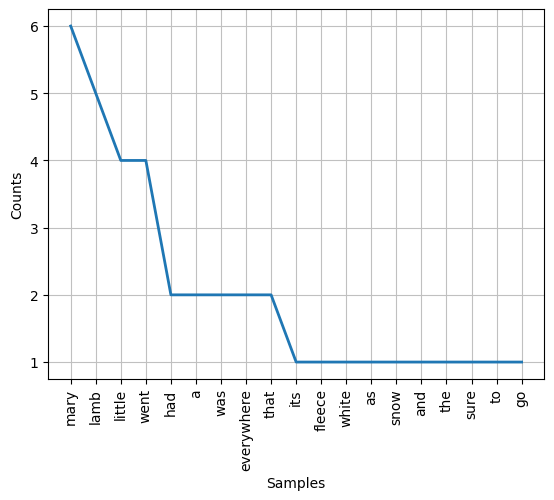

In [ ]:
# Create a TextCollection object to compute TF-IDF values
nlp = TextCollection(corpus)

# Plot term frequency distribution
nlp.plot()

In [ ]:
# Calculate TF-IDF values for each word in each document
TFIDF = []

for doc in corpus:
    current = {}
    for token in doc:
        current[token] = nlp.tf_idf(token, doc)
    TFIDF.append(current)

TFIDF

[{'mary': 0.0,
  'had': 0.04505167867868493,
  'a': 0.04505167867868493,
  'little': 0.13515503603605478,
  'lamb': 0.0},
 {'mary': 0.0,
  'had': 0.036860464373469494,
  'a': 0.036860464373469494,
  'little': 0.036860464373469494,
  'lamb': 0.0,
  'its': 0.09987384442437362,
  'fleece': 0.09987384442437362,
  'was': 0.036860464373469494,
  'white': 0.09987384442437362,
  'as': 0.09987384442437362,
  'snow': 0.09987384442437362},
 {'and': 0.057821699403584725,
  'everywhere': 0.11564339880716945,
  'that': 0.11564339880716945,
  'mary': 0.0,
  'went': 0.2312867976143389,
  'the': 0.057821699403584725,
  'lamb': 0.0,
  'was': 0.021340268847798126,
  'sure': 0.057821699403584725,
  'to': 0.057821699403584725,
  'go': 0.057821699403584725}]

## N-grams

In [ ]:
# Function to generate n-grams from the tokenized text
def get_ngrams(text, length):
    from nltk.util import ngrams

    n_grams = ngrams(tokenize(text), length)
    return [' '.join(grams) for grams in n_grams]

In [ ]:
# Generate bigrams (2-word sequences)
get_ngrams(text.lower(), 2)

['mary had',
 'had a',
 'a little',
 'little lamb',
 'lamb little',
 'little lamb',
 'lamb little',
 'little lamb',
 'lamb mary',
 'mary had',
 'had a',
 'a little',
 'little lamb',
 'lamb its',
 'its fleece',
 'fleece was',
 'was white',
 'white as',
 'as snow',
 'snow and',
 'and everywhere',
 'everywhere that',
 'that mary',
 'mary went',
 'went mary',
 'mary went',
 'went mary',
 'mary went',
 'went everywhere',
 'everywhere that',
 'that mary',
 'mary went',
 'went the',
 'the lamb',
 'lamb was',
 'was sure',
 'sure to',
 'to go']

## Collocations

In [ ]:
# Find bigram collocations (frequent word pairings)
bigrams = BigramCollocationFinder.from_words(tokenize(text, False))

# Score bigrams using likelihood ratio
scored = bigrams.score_ngrams(BigramAssocMeasures.likelihood_ratio)

scored

[(('little', 'lamb'), 20.789064969512463),
 (('mary', 'went'), 18.154919185356587),
 (('everywhere', 'that'), 15.777294140200038),
 (('had', 'a'), 15.777294140200038),
 (('a', 'little'), 10.232116695720478),
 (('as', 'snow'), 9.301260258907092),
 (('its', 'fleece'), 9.301260258907092),
 (('snow', 'and'), 9.301260258907092),
 (('sure', 'to'), 9.301260258907092),
 (('to', 'go'), 9.301260258907092),
 (('white', 'as'), 9.301260258907092),
 (('mary', 'had'), 8.139124120662284),
 (('that', 'mary'), 8.139124120662284),
 (('and', 'everywhere'), 6.528671536667327),
 (('fleece', 'was'), 6.528671536667327),
 (('was', 'sure'), 6.528671536667327),
 (('was', 'white'), 6.528671536667327),
 (('went', 'the'), 4.802579101956642),
 (('lamb', 'its'), 4.297236023525216),
 (('the', 'lamb'), 4.297236023525216),
 (('lamb', 'little'), 3.850143362325084),
 (('went', 'mary'), 3.065215528887738),
 (('went', 'everywhere'), 2.196764352889584),
 (('lamb', 'was'), 1.7502532877068806),
 (('lamb', 'mary'), 0.0881930648